# Chapter 3 — Classification

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                      StratifiedKFold, GridSearchCV, train_test_split)
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score,
                              precision_recall_curve, roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.base import BaseEstimator, TransformerMixin, clone

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

## MNIST

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [4]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

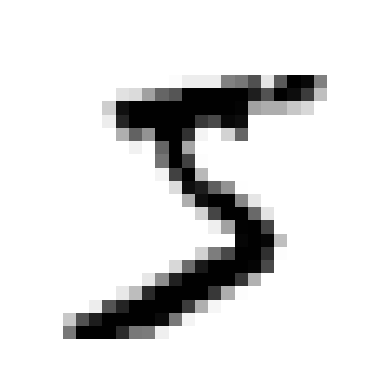

In [5]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [6]:
y[0]

'5'

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

In [8]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

sgd_clf.predict([some_digit])

array([ True])

## Performance Measures

### Measuring Accuracy Using Cross-Validation

In [10]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [11]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [12]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

### Implementing Cross-Validation

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is
# not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred)) # prints 0.95035, 0.96035, and 0.9604

0.95035
0.96035
0.9604


## Confusion Matrix

In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, n_jobs=3)

In [15]:
y_train_pred

array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [16]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [17]:
y_train_perfect_prediction = y_train_5 # pretend we reached perfection
cm_perfect = confusion_matrix(y_train_5, y_train_perfect_prediction)
cm_perfect

array([[54579,     0],
       [    0,  5421]])

### Interpretación de la matriz de confusión (TN, FP, FN, TP)

Para clasificación binaria (aquí: **“es 5”** vs **“no es 5”**), la matriz sigue este orden en `sklearn`:

\[
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
\]

Con tu matriz `cm`:

\[
\begin{bmatrix}
53892 & 687 \\
1891 & 3530
\end{bmatrix}
\]

- **TN (True Negatives) = 53,892**  
    El modelo predijo **“no es 5”** y realmente **no era 5**.

- **FP (False Positives) = 687**  
    El modelo predijo **“es 5”**, pero en realidad **no era 5** (falsas alarmas).

- **FN (False Negatives) = 1,891**  
    El modelo predijo **“no es 5”**, pero en realidad **sí era 5** (5s que se escaparon).

- **TP (True Positives) = 3,530**  
    El modelo predijo **“es 5”** y realmente **sí era 5**.

---

**Resumen rápido:** tu clasificador comete más **FN** que **FP**, o sea, tiende más a perder algunos “5” reales que a inventar “5” donde no los hay.

## Precision and Recall

In [18]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred) 

0.8370879772350012

In [19]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [20]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

## The Presicion/Recall Trade-Off

In [21]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [22]:
trueshold = 0
y_some_digit_pred = (y_scores > trueshold)
y_some_digit_pred

array([ True])

In [23]:
trueshold = 3000
y_some_digit_pred = (y_scores > trueshold)
y_some_digit_pred

array([False])

In [24]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function', n_jobs=3)
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

In [25]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [26]:
from plotnine import * 

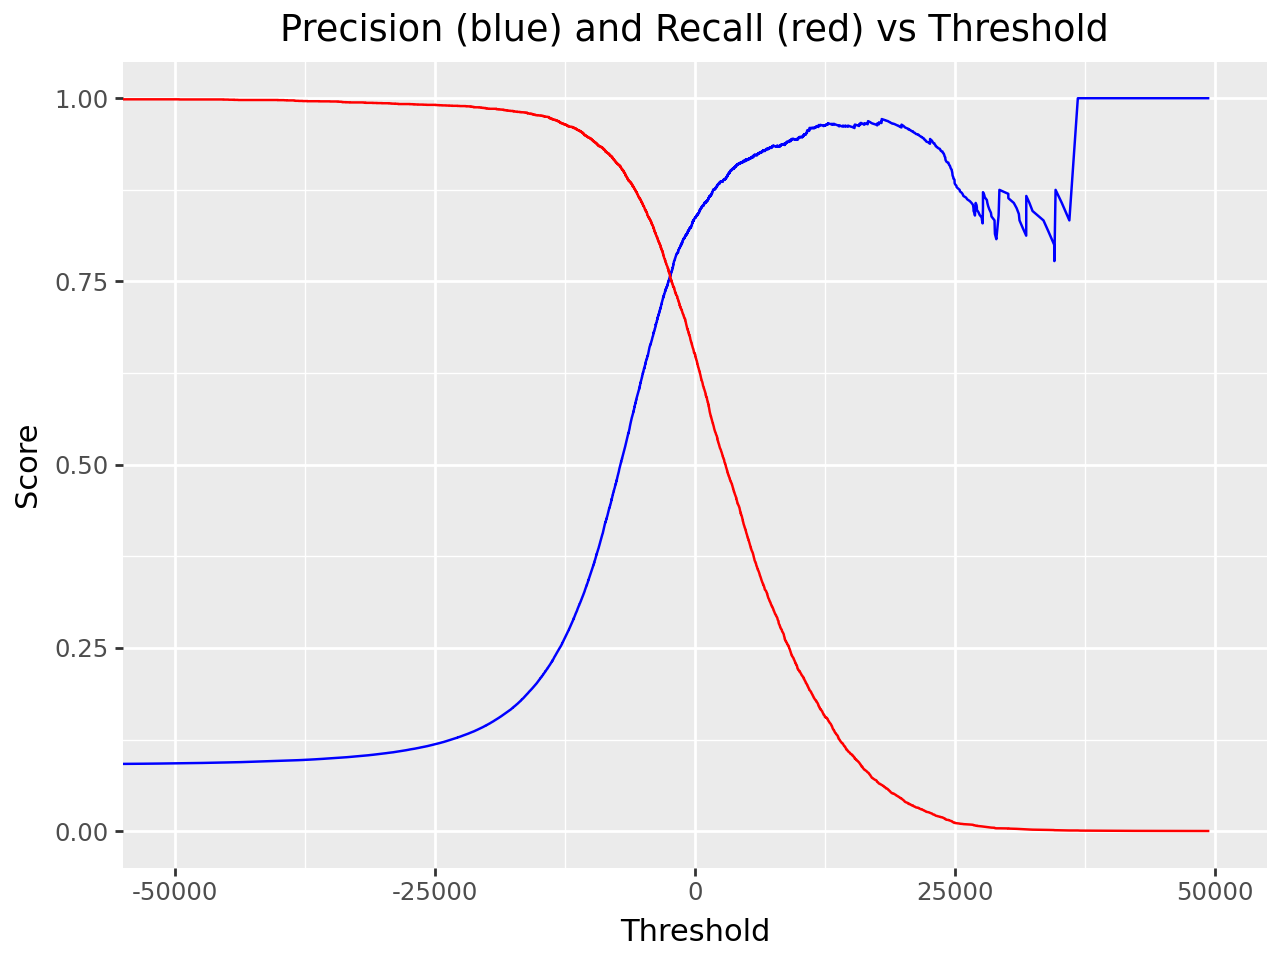

In [27]:
# Plot precision and recall as a function of the threshold with plotnine
# (limited x-axis range from -5000 to 500)
(
    ggplot(
        data=pd.DataFrame({
            'thresholds': thresholds,
            'precisions': precisions[:-1],
            'recalls': recalls[:-1]
        })
    )
    + geom_line(aes(x='thresholds', y='precisions'), color='blue')
    + geom_line(aes(x='thresholds', y='recalls'), color='red')
    + coord_cartesian(xlim=(-50000, 50000))
    + labs(
        x='Threshold',
        y='Score',
        title='Precision (blue) and Recall (red) vs Threshold'
    )
)

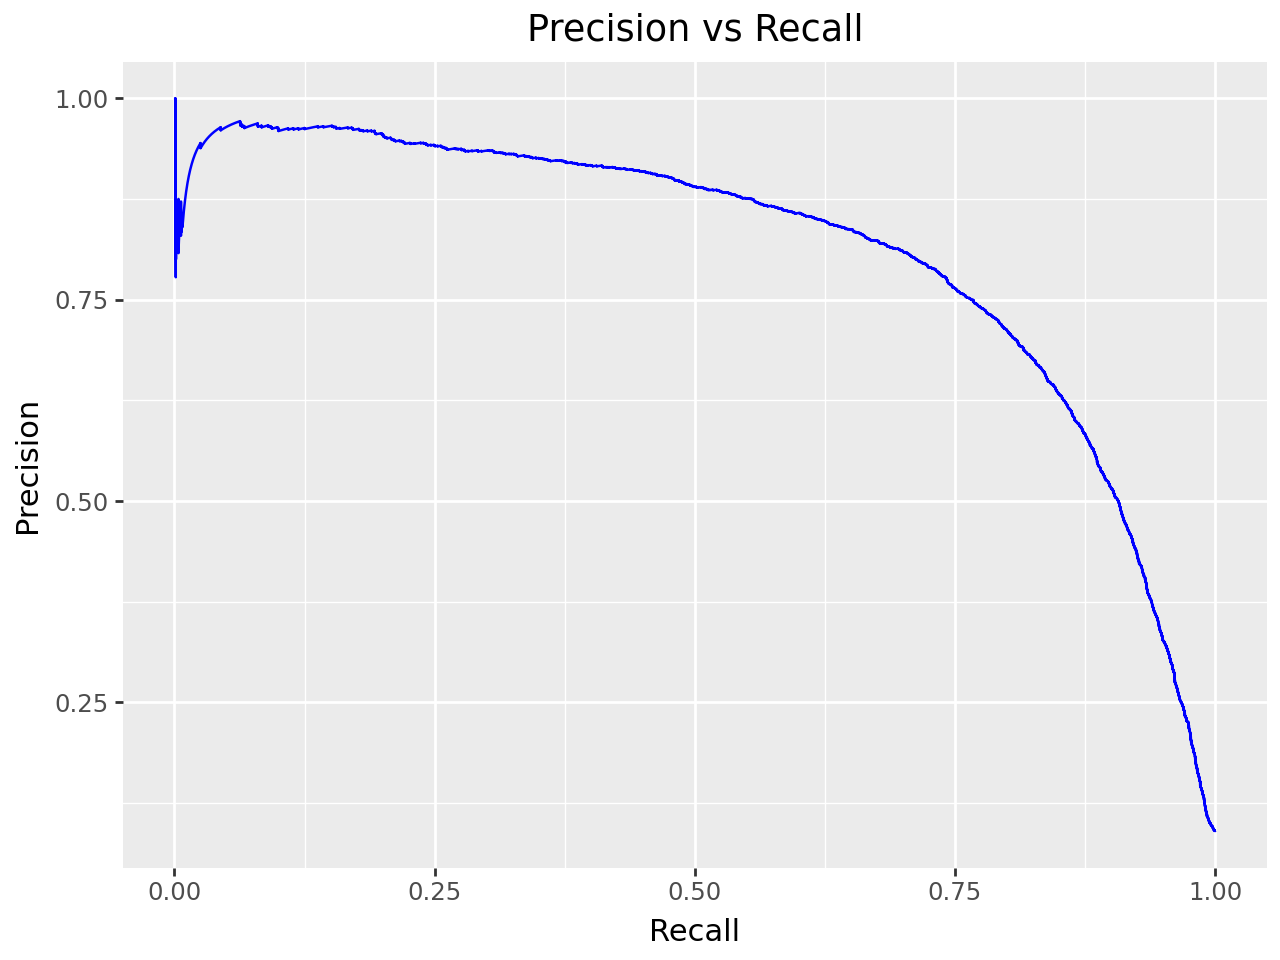

In [28]:
# Otro grafico con la ys de presicion y recall, pero con el eje x como recall
(
    ggplot(
        data=pd.DataFrame({
            'thresholds': thresholds,
            'precisions': precisions[:-1],
            'recalls': recalls[:-1]
        })
    )
    + geom_line(aes(x='recalls', y='precisions'), color='blue')
    + labs(
        x='Recall',
        y='Precision',
        title='Precision vs Recall'
    )
)

In [29]:
import numpy as np
from sklearn.metrics import precision_recall_curve

#precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)

f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_precision = precisions[best_index]
best_recall = recalls[best_index]

print("Best threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1:", f1_scores[best_index])

Best threshold: -1991.7400221489
Precision: 0.7780360255665311
Recall: 0.7410071942446043
F1: 0.7590702947840807


In [31]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision 

np.float64(3370.0194991439585)

In [33]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [34]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

## The ROC Curve

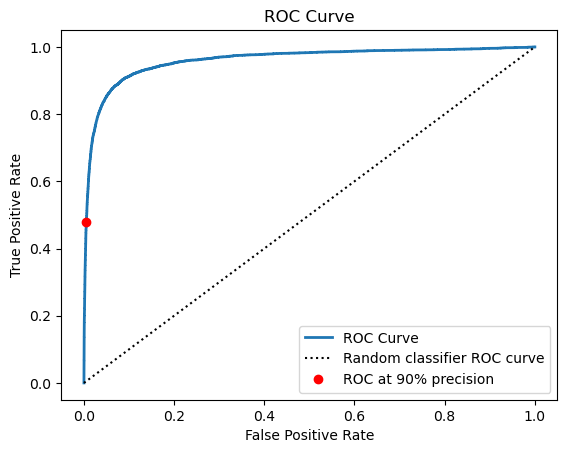

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k:', label='Random classifier ROC curve')
plt.plot(fpr_90, tpr_90, 'ro', label='ROC at 90% precision')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

Se usa ROC-AUC cuando el balanceo de clases es bueno, mientras que Precision-Recall es mejor para clases desbalanceadas. En MNIST, el “5” es una clase minoritaria, por lo que Precision-Recall es más informativo.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)